# All-Cuisine Classification Model Benchmark

This notebook predicts all **82 atomic cuisine/category labels** in the synthetic order history. It compares 12 classifier families, selects the winner using validation accuracy, and evaluates it once on an untouched test set.

Each feature row uses only the user's earlier orders. First orders are excluded because they have no history yet.

## 1. Setup

### Import general-purpose libraries

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import csv
import gc

'd:\\The Intelligent Culinary Matchmaker & Personalized Menu Agent\\culinary_matchmaker\\notebooks\\.matplotlib'

### Import machine-learning libraries

In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

### Locate the project and define paths

In [3]:
def find_project_root(start_directory):
    # Support running from either the project root or the notebooks folder.
    start_directory = Path(start_directory).resolve()
    for folder in [start_directory, *start_directory.parents]:
        if (folder / "data" / "cuisine_taxonomy.csv").is_file():
            return folder
        if (folder / "culinary_matchmaker" / "data" / "cuisine_taxonomy.csv").is_file():
            return folder / "culinary_matchmaker"
    raise FileNotFoundError("Could not find culinary_matchmaker/data/cuisine_taxonomy.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "user_order_history.csv"
TAXONOMY_PATH = PROJECT_ROOT / "data" / "cuisine_taxonomy.csv"
MODELS_DIR = PROJECT_ROOT / "models"

### Set folders and constants

In [4]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MINIMUM_ACCURACY = 0.75
MINIMUM_HISTORY_ORDERS = 1
TARGET_COLUMN = "ordered_cuisine"

print("Project root:", PROJECT_ROOT)

Project root: D:\The Intelligent Culinary Matchmaker & Personalized Menu Agent\culinary_matchmaker


## 2. Build Leakage-Safe Historical Features

### Load and validate the cuisine taxonomy

In [5]:
with TAXONOMY_PATH.open("r", encoding="utf-8-sig", newline="") as file:
    taxonomy = [row["cuisine"].strip() for row in csv.DictReader(file)]

if not taxonomy or len(taxonomy) != len(set(taxonomy)):
    raise ValueError("Cuisine taxonomy is empty or contains duplicates")

print("Taxonomy classes:", len(taxonomy))

Taxonomy classes: 82


### Create prior-order features

The user's state is read **before** the current order and updated **afterward**. This ordering is essential because using the current cuisine in its own input features would leak the answer into the model.

In [6]:
def engineer_historical_features(data_path, expected_classes):
    user_history = defaultdict(
        lambda: {"orders": 0, "rating_sum": 0.0, "cuisine_counts": Counter()}
    )
    features, targets = [], []

    with data_path.open("r", encoding="utf-8-sig", newline="") as file:
        reader = csv.DictReader(file)
        required_columns = {
            "user_id", "meal_time", "day_type", "vegetarian",
            "spice_preference", "rating", TARGET_COLUMN,
        }
        missing = required_columns - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f"Order history is missing columns: {sorted(missing)}")

        for row_number, row in enumerate(reader, start=2):
            user_id = row["user_id"].strip()
            target = row[TARGET_COLUMN].strip()
            history = user_history[user_id]
            cuisine_counts = history["cuisine_counts"]

            if cuisine_counts:
                favourite_cuisine, favourite_count = cuisine_counts.most_common(1)[0]
            else:
                favourite_cuisine, favourite_count = "Unknown", 0

            average_rating = (
                history["rating_sum"] / history["orders"]
                if history["orders"] else 4.0
            )
            feature_row = {
                "user_id": user_id,
                "meal_time": row["meal_time"].strip(),
                "day_type": row["day_type"].strip(),
                "vegetarian": row["vegetarian"].strip(),
                "average_previous_rating": round(average_rating, 3),
                "most_ordered_cuisine": favourite_cuisine,
                "order_frequency": history["orders"],
                "spice_preference": row["spice_preference"].strip(),
                "previous_cuisine_orders": favourite_count,
            }
            if not all(str(value).strip() for value in feature_row.values()):
                raise ValueError(f"Blank feature generated at source row {row_number}")

            features.append(feature_row)
            targets.append(target)

            history["orders"] += 1
            history["rating_sum"] += float(row["rating"])
            cuisine_counts[target] += 1

    if set(targets) != expected_classes:
        missing = expected_classes - set(targets)
        extra = set(targets) - expected_classes
        raise ValueError(f"Target/taxonomy mismatch. Missing={sorted(missing)}, extra={sorted(extra)}")

    return features, targets

### Exclude first orders with no user history

In [7]:
all_features, all_targets = engineer_historical_features(DATA_PATH, set(taxonomy))

eligible_rows = [
    (feature_row, target)
    for feature_row, target in zip(all_features, all_targets)
    if feature_row["order_frequency"] >= MINIMUM_HISTORY_ORDERS
]
features = [feature_row for feature_row, _ in eligible_rows]
targets = [target for _, target in eligible_rows]
excluded_cold_start_rows = len(all_features) - len(features)
target_counts = Counter(targets)

print("History rows:", len(all_features))
print("Returning-user rows:", len(features))
print("Cold-start rows excluded:", excluded_cold_start_rows)
print("Target class size range:", min(target_counts.values()), "to", max(target_counts.values()))

History rows: 40000
Returning-user rows: 35000
Cold-start rows excluded: 5000
Target class size range: 121 to 1673


## 3. Prepare Train, Validation, and Test Data

### Encode the target and create stratified splits

In [8]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(targets)

x_development_rows, x_test_rows, y_development, y_test = train_test_split(
    features, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y,
)
x_train_rows, x_validation_rows, y_train, y_validation = train_test_split(
    x_development_rows,
    y_development,
    test_size=0.15 / 0.85,  # Makes validation 15% of all rows.
    random_state=RANDOM_STATE,
    stratify=y_development,
)

print("Training rows:", len(x_train_rows))
print("Validation rows:", len(x_validation_rows))
print("Untouched test rows:", len(x_test_rows))

Training rows: 24500
Validation rows: 5250
Untouched test rows: 5250


### Convert mixed features into a sparse numeric matrix

In [9]:
def compact_sparse(matrix):
    # SVM and SGD require 32-bit sparse-matrix indices here.
    matrix = matrix.tocsr()
    return csr_matrix(
        (matrix.data, matrix.indices.astype(np.int32), matrix.indptr.astype(np.int32)),
        shape=matrix.shape,
    )


benchmark_preprocessor = DictVectorizer(sparse=True)
x_train = compact_sparse(benchmark_preprocessor.fit_transform(x_train_rows))
x_validation = compact_sparse(benchmark_preprocessor.transform(x_validation_rows))

print("Encoded features:", x_train.shape[1])

Encoded features: 5059


## 4. Compare Classification Models

### Define all 12 model families

In [10]:
models = {
    "Dummy Most Frequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Ridge Classifier": RidgeClassifier(class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    "RBF SVM": SVC(C=3.0, kernel="rbf", gamma="scale", class_weight="balanced", cache_size=500),
    "SGD Logistic": SGDClassifier(
        loss="log_loss", max_iter=2000, class_weight="balanced",
        early_stopping=True, random_state=RANDOM_STATE,
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=11, weights="distance", n_jobs=1),
    "Complement Naive Bayes": ComplementNB(alpha=0.5),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=35, min_samples_leaf=2, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=80, max_depth=25, min_samples_leaf=1, max_features=0.20,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=35, min_samples_leaf=1, max_features=0.35,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob", num_class=len(label_encoder.classes_), n_estimators=35,
        max_depth=4, max_bin=64, learning_rate=0.18, subsample=0.9,
        colsample_bytree=0.75, tree_method="hist", n_jobs=2, random_state=RANDOM_STATE,
    ),
}

print("Models to compare:", len(models))

Models to compare: 12


### Define small reusable benchmark steps

In [11]:
def calculate_metrics(actual, predicted):
    return {
        "accuracy": float(accuracy_score(actual, predicted)),
        "precision_weighted": float(precision_score(actual, predicted, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(actual, predicted, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(actual, predicted, average="weighted", zero_division=0)),
        "f1_macro": float(f1_score(actual, predicted, average="macro", zero_division=0)),
    }


def train_model(name, model, x_data, y_data):
    if name == "XGBoost":
        weights = compute_sample_weight(class_weight="balanced", y=y_data)
        return model.fit(x_data, y_data, sample_weight=weights)
    return model.fit(x_data, y_data)


def predict_model(name, model, x_data):
    if name != "K-Nearest Neighbors":
        return model.predict(x_data)
    batches = [model.predict(x_data[start:start + 250]) for start in range(0, x_data.shape[0], 250)]
    return np.concatenate(batches)

### Train and validate every model

In [12]:
benchmark_results = []

for name, model_template in models.items():
    fitted_model = None
    try:
        fitted_model = train_model(name, clone(model_template), x_train, y_train)
        predictions = predict_model(name, fitted_model, x_validation)
        result = {
            "model": name,
            **calculate_metrics(y_validation, predictions),
        }
        benchmark_results.append(result)
        print(
            f"{name:24s} accuracy={result['accuracy']:.4f} "
            f"weighted_f1={result['f1_weighted']:.4f}"
        )
    except Exception as error:
        print(f"{name:24s} FAILED: {error}")

    del fitted_model
    gc.collect()

benchmark_results.sort(
    key=lambda row: (row["accuracy"], row["f1_weighted"]), reverse=True
)

Dummy Most Frequent      accuracy=0.0478 weighted_f1=0.0044
Logistic Regression      accuracy=0.8857 weighted_f1=0.8856
Ridge Classifier         accuracy=0.8800 weighted_f1=0.8799
Linear SVM               accuracy=0.8920 weighted_f1=0.8918
RBF SVM                  accuracy=0.8857 weighted_f1=0.8856
SGD Logistic             accuracy=0.8804 weighted_f1=0.8805
K-Nearest Neighbors      accuracy=0.6813 weighted_f1=0.6741
Complement Naive Bayes   accuracy=0.8918 weighted_f1=0.8917
Decision Tree            accuracy=0.1928 weighted_f1=0.1798
Extra Trees              accuracy=0.2985 weighted_f1=0.2889
Random Forest            accuracy=0.4093 weighted_f1=0.3968
XGBoost                  accuracy=0.8857 weighted_f1=0.8856


### Select and display the validation winner

In [13]:
if not benchmark_results:
    raise RuntimeError("Every classifier failed")

winner_name = benchmark_results[0]["model"]
print("Validation leaderboard")
for rank, row in enumerate(benchmark_results, start=1):
    print(f"{rank:2d}. {row['model']:24s} accuracy={row['accuracy']:.4f} weighted_f1={row['f1_weighted']:.4f}")
print("Selected model:", winner_name)

Validation leaderboard
 1. Linear SVM               accuracy=0.8920 weighted_f1=0.8918
 2. Complement Naive Bayes   accuracy=0.8918 weighted_f1=0.8917
 3. RBF SVM                  accuracy=0.8857 weighted_f1=0.8856
 4. Logistic Regression      accuracy=0.8857 weighted_f1=0.8856
 5. XGBoost                  accuracy=0.8857 weighted_f1=0.8856
 6. SGD Logistic             accuracy=0.8804 weighted_f1=0.8805
 7. Ridge Classifier         accuracy=0.8800 weighted_f1=0.8799
 8. K-Nearest Neighbors      accuracy=0.6813 weighted_f1=0.6741
 9. Random Forest            accuracy=0.4093 weighted_f1=0.3968
10. Extra Trees              accuracy=0.2985 weighted_f1=0.2889
11. Decision Tree            accuracy=0.1928 weighted_f1=0.1798
12. Dummy Most Frequent      accuracy=0.0478 weighted_f1=0.0044
Selected model: Linear SVM


## 5. Train and Evaluate the Winner

### Retrain the selected model on all development data

In [14]:
del x_train, x_validation, benchmark_preprocessor
gc.collect()

final_preprocessor = DictVectorizer(sparse=True)
x_development = compact_sparse(final_preprocessor.fit_transform(x_development_rows))
x_test = compact_sparse(final_preprocessor.transform(x_test_rows))
selected_model = clone(models[winner_name])

if hasattr(selected_model, "predict_proba"):
    final_model = train_model(winner_name, selected_model, x_development, y_development)
else:
    final_model = CalibratedClassifierCV(
        selected_model, method="sigmoid", cv=3, n_jobs=1
    ).fit(x_development, y_development)

print("Retrained and probability-calibrated:", winner_name)

Retrained and probability-calibrated: Linear SVM


### Evaluate once on the untouched test set

In [15]:
test_predictions = final_model.predict(x_test)
final_metrics = calculate_metrics(y_test, test_predictions)

print("Untouched test metrics")
for metric_name, value in final_metrics.items():
    print(f"  {metric_name}: {value:.4f}")

if final_metrics["accuracy"] < MINIMUM_ACCURACY:
    raise RuntimeError("Selected model did not meet the required test accuracy")

Untouched test metrics
  accuracy: 0.9042
  precision_weighted: 0.9053
  recall_weighted: 0.9042
  f1_weighted: 0.9040
  f1_macro: 0.9123


## 6. Save Runtime Model Artifacts

### Save the model, preprocessor, and label encoder

In [16]:
joblib.dump(final_model, MODELS_DIR / "cuisine_classifier.pkl")
joblib.dump(final_preprocessor, MODELS_DIR / "preprocessors.pkl")
joblib.dump(label_encoder, MODELS_DIR / "label_encoder.pkl")

print("Saved model artifacts in:", MODELS_DIR)

Saved: D:\The Intelligent Culinary Matchmaker & Personalized Menu Agent\culinary_matchmaker\models\cuisine_classifier.pkl
Saved: D:\The Intelligent Culinary Matchmaker & Personalized Menu Agent\culinary_matchmaker\models\preprocessors.pkl
Saved: D:\The Intelligent Culinary Matchmaker & Personalized Menu Agent\culinary_matchmaker\models\label_encoder.pkl


### Display the normalized confusion matrix

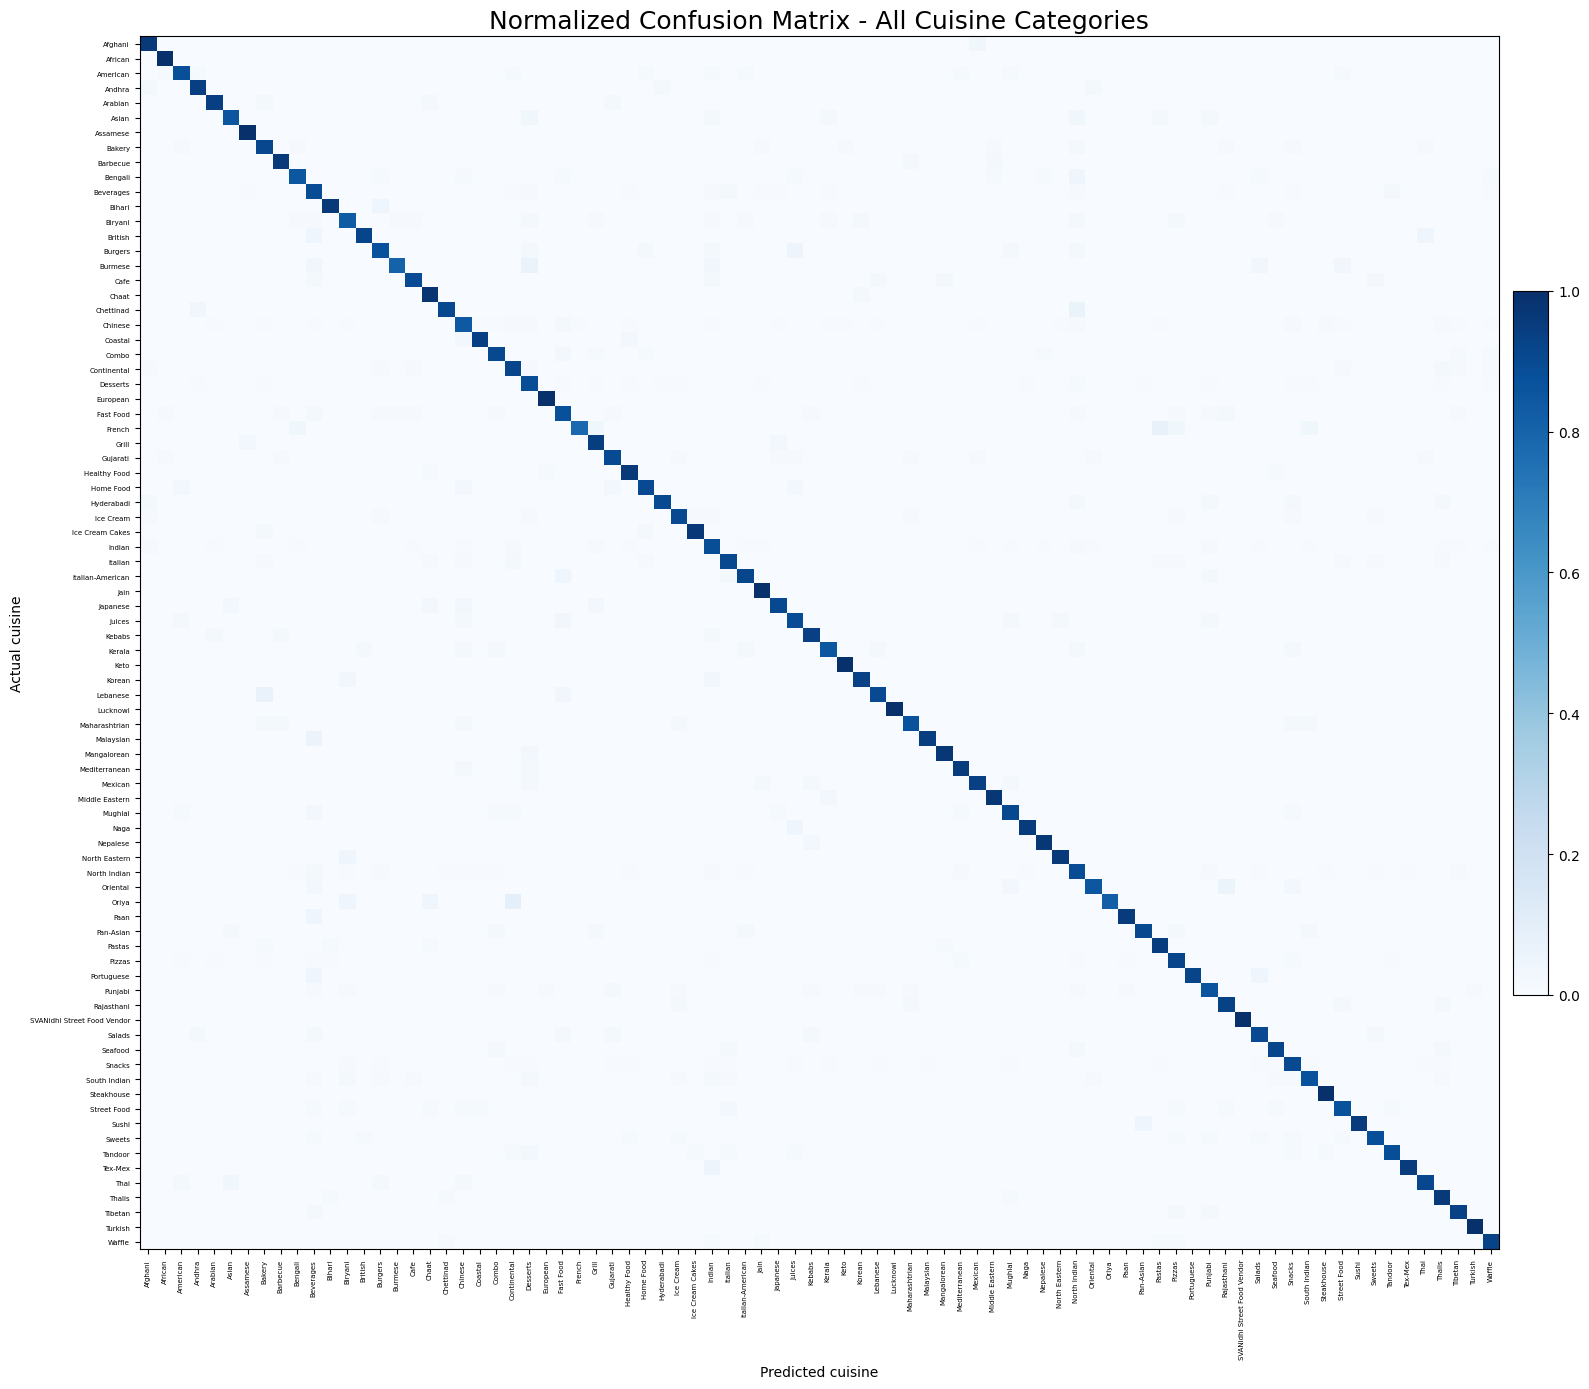

In [17]:
class_names = label_encoder.classes_.tolist()
matrix = confusion_matrix(y_test, test_predictions, labels=range(len(class_names)))
normalized_matrix = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)

figure, axis = plt.subplots(figsize=(16, 14))
image = axis.imshow(normalized_matrix, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axis.set_title("Normalized Confusion Matrix - All Cuisine Categories", fontsize=18)
axis.set_xlabel("Predicted cuisine")
axis.set_ylabel("Actual cuisine")
axis.set_xticks(range(len(class_names)), class_names, rotation=90, fontsize=5)
axis.set_yticks(range(len(class_names)), class_names, fontsize=5)
figure.colorbar(image, ax=axis, fraction=0.025, pad=0.01)
figure.tight_layout()
plt.show()

## 7. Make a Sample Prediction

### Predict and display the top 10 cuisines

In [19]:
sample_user = {
    "user_id": "U00042",
    "meal_time": "Dinner",
    "day_type": "Weekend",
    "vegetarian": "Yes",
    "average_previous_rating": 4.4,
    "most_ordered_cuisine": "North Indian",
    "order_frequency": 12,
    "spice_preference": "Hot",
    "previous_cuisine_orders": 9,
}

sample_matrix = compact_sparse(final_preprocessor.transform([sample_user]))
probabilities = final_model.predict_proba(sample_matrix)[0]
predicted_classes = label_encoder.inverse_transform(final_model.classes_)
ranked_predictions = sorted(
    zip(predicted_classes, probabilities), key=lambda item: item[1], reverse=True
)

print("Top 10 cuisine predictions")
for cuisine, probability in ranked_predictions[:10]:
    print(f"{cuisine:30s} {probability:.2%}")

Top 10 cuisine predictions
North Indian                   86.37%
Chinese                        0.95%
Biryani                        0.91%
Indian                         0.80%
Snacks                         0.75%
Beverages                      0.72%
Tandoor                        0.51%
Pastas                         0.49%
Pizzas                         0.48%
South Indian                   0.43%


## Interpretation

These results describe held-out **synthetic returning-user data**. They demonstrate the complete comparison pipeline and coverage of all cuisine classes, but genuine user-order history is required before making real-world accuracy claims.